# 1. Introduction

This EDA notebook uses the processed Toronto traffic flow datasets to explore temporal demand variation, peak-hour behavior, and operational insights that matter for traffic signal timing optimization.


## Scope and Limitation

The analysis focuses on the raw-derived 2015-2019 baseline. Because the SVC program is campaign-based rather than continuously monitored, the most defensible conclusions emphasize recurring citywide and location-level demand patterns rather than uninterrupted per-site trajectories.


## 2. Data Overview


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start


repo_root = find_repo_root(Path.cwd())
daily_path = repo_root / "data" / "processed" / "modeling_dataset_2015_2019.csv"
hourly_path = repo_root / "data" / "processed" / "traffic_signal_hourly_dataset_2015_2019.csv"

for path in [daily_path, hourly_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run notebooks/00_raw_preprocessing.ipynb first.")

daily_df = pd.read_csv(daily_path, parse_dates=["date"])
hourly_df = pd.read_csv(hourly_path, parse_dates=["hour", "date"])

print(f"Loaded daily dataset: {daily_path}")
print(f"Loaded hourly dataset: {hourly_path}")
print(f"daily_df.shape: {daily_df.shape[0]} rows x {daily_df.shape[1]} columns")
print(f"hourly_df.shape: {hourly_df.shape[0]} rows x {hourly_df.shape[1]} columns")


Loaded daily dataset: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/modeling_dataset_2015_2019.csv
Loaded hourly dataset: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/traffic_signal_hourly_dataset_2015_2019.csv
daily_df.shape: 5778 rows x 16 columns
hourly_df.shape: 138672 rows x 21 columns


In [2]:
display(daily_df.head())


,location_id,date,location_name,centreline_id,direction,year,month,day_of_week,is_weekend,daily_total_volume,peak_hour_volume,observed_hour_count,avg_observed_hourly_volume,peak_ratio,peak_hour_concentration,queue_pressure_proxy
0,10010625_WB,2015-05-14,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,3,0,17031,1809,24,709.625000,0.106218,2.549234,1099.375000
1,10010625_WB,2015-05-15,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,4,0,17365,1734,24,723.541667,0.099856,2.396545,1010.458333
2,10010625_WB,2015-05-16,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,5,1,14470,1066,24,602.916667,0.073670,1.768072,463.083333
3,10010625_WB,2015-05-17,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,6,1,12235,973,24,509.791667,0.079526,1.908623,463.208333
4,10010625_WB,2015-05-18,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015,5,0,0,16523,1775,24,688.458333,0.107426,2.578224,1086.541667


In [3]:
display(daily_df.describe(include='all').T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
location_id,5778,914,103009_NB,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,5778,NaN,NaN,NaN,2016-12-06 12:22:25.794392,2015-03-31 00:00:00,2015-06-04 06:00:00,2016-06-04 00:00:00,2018-06-02 00:00:00,2019-11-05 00:00:00,NaN
location_name,5778,711,Sewells Rd: Old Finch Ave - Steeles Ave E,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
centreline_id,5778.0,NaN,NaN,NaN,10477128.899446,415.0,906778.0,7792640.5,14037408.0,60042531.0,12973711.664557
direction,5778,4,NB,1460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,5778.0,NaN,NaN,NaN,2016.472655,2015.0,2015.0,2016.0,2018.0,2019.0,1.397479
month,5778.0,NaN,NaN,NaN,6.109034,1.0,5.0,6.0,8.0,12.0,2.895721
day_of_week,5778.0,NaN,NaN,NaN,2.674974,0.0,1.0,2.0,4.0,6.0,1.783097
is_weekend,5778.0,NaN,NaN,NaN,0.196435,0.0,0.0,0.0,0.0,1.0,0.397335
daily_total_volume,5778.0,NaN,NaN,NaN,10875.843891,0.0,7235.5,10792.5,14577.75,40994.0,5835.897287


## 3. Missing Values and Data Quality


In [4]:
missing_counts = daily_df.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0].to_frame("missing_count"))


,missing_count
peak_ratio,1
peak_hour_concentration,1


In [5]:
quality_flags = {
    "duplicate_daily_rows": int(daily_df.duplicated().sum()),
    "duplicate_hourly_rows": int(hourly_df.duplicated().sum()),
    "negative_daily_total_volume": int((daily_df["daily_total_volume"] < 0).sum()),
    "negative_peak_hour_volume": int((daily_df["peak_hour_volume"] < 0).sum()),
    "invalid_peak_ratio_lt_0": int((daily_df["peak_ratio"] < 0).sum()),
    "invalid_peak_ratio_gt_1": int((daily_df["peak_ratio"] > 1).sum()),
}

display(pd.Series(quality_flags, name="count"))


duplicate_daily_rows           0
duplicate_hourly_rows          0
negative_daily_total_volume    0
negative_peak_hour_volume      0
invalid_peak_ratio_lt_0        0
invalid_peak_ratio_gt_1        0
Name: count, dtype: int64

In [6]:
def iqr_outlier_count(series: pd.Series) -> int:
    x = series.dropna()
    if x.empty:
        return 0
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return int(((x < lo) | (x > hi)).sum())


outlier_report = {
    c: iqr_outlier_count(daily_df[c])
    for c in ["daily_total_volume", "peak_hour_volume", "peak_ratio", "peak_hour_concentration"]
    if c in daily_df.columns
}

display(pd.Series(outlier_report, name="iqr_outlier_rows"))


daily_total_volume          62
peak_hour_volume            65
peak_ratio                 384
peak_hour_concentration    384
Name: iqr_outlier_rows, dtype: int64

## 4. Traffic Demand Trends Over Time


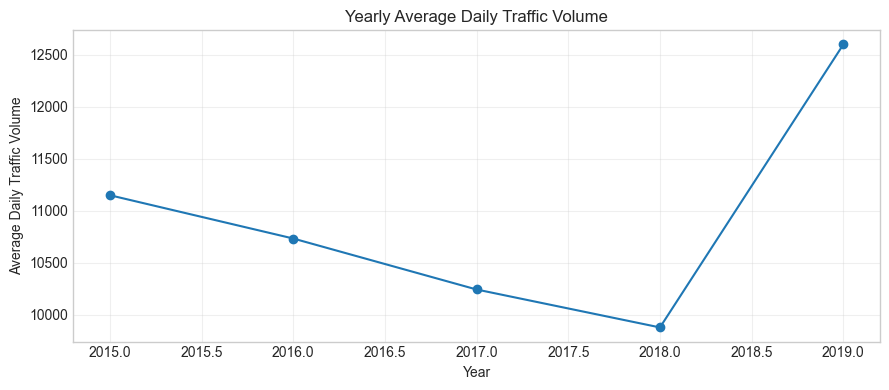

In [7]:
yearly = (
    daily_df.dropna(subset=["date", "daily_total_volume"])
    .groupby(daily_df["date"].dt.year, as_index=False)["daily_total_volume"]
    .mean()
)

plt.figure(figsize=(9, 4))
plt.plot(yearly["date"], yearly["daily_total_volume"], marker="o")
plt.title("Yearly Average Daily Traffic Volume")
plt.xlabel("Year")
plt.ylabel("Average Daily Traffic Volume")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


This yearly view acts as a baseline stability check. For the capstone objective, the key value is a consistent pre-COVID demand range rather than trend extrapolation.


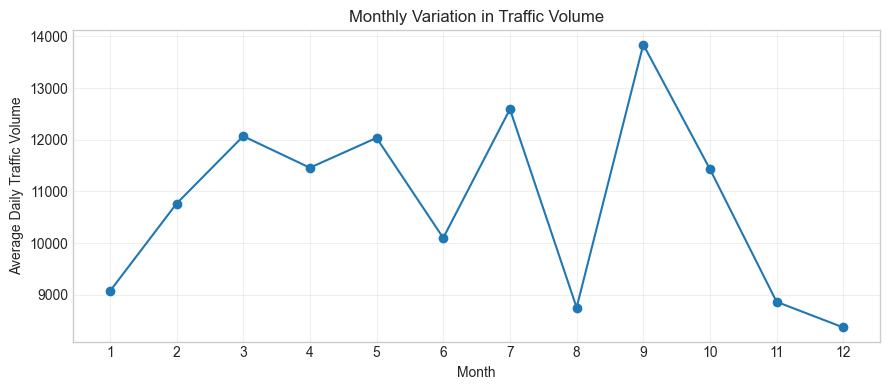

In [8]:
monthly = (
    daily_df.dropna(subset=["date", "daily_total_volume"])
    .assign(month=daily_df["date"].dt.month)
    .groupby("month", as_index=False)["daily_total_volume"]
    .mean()
)

plt.figure(figsize=(9, 4))
plt.plot(monthly["month"], monthly["daily_total_volume"], marker="o")
plt.xticks(range(1, 13))
plt.title("Monthly Variation in Traffic Volume")
plt.xlabel("Month")
plt.ylabel("Average Daily Traffic Volume")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Monthly variation identifies when typical demand is stronger or weaker across the year. This is useful for deciding whether a single static signal plan is defensible or whether seasonal plan adjustments may be warranted.


## 5. Weekly and Peak-Hour Patterns


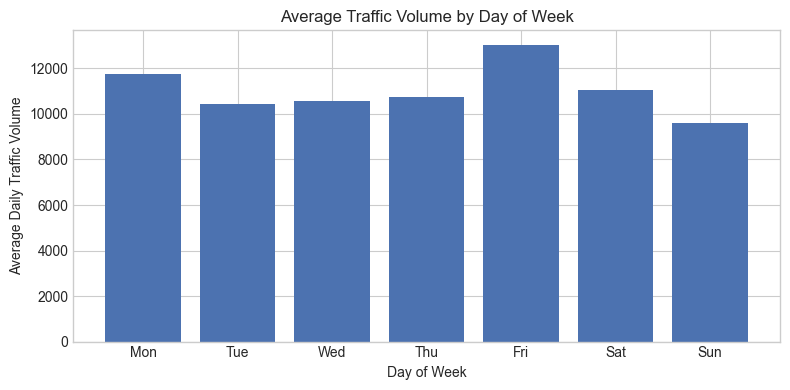

In [9]:
dow_src = daily_df.dropna(subset=["day_of_week", "daily_total_volume"]).copy()
dow_src["day_of_week"] = pd.to_numeric(dow_src["day_of_week"], errors="coerce")

dow = (
    dow_src.dropna(subset=["day_of_week"])
    .groupby("day_of_week", as_index=False)
    .agg(daily_total_volume=("daily_total_volume", "mean"))
    .sort_values(by="day_of_week")
    .reset_index(drop=True)
)

dow["day_of_week"] = dow["day_of_week"].astype(int)
name_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow["day_name"] = dow["day_of_week"].map(name_map)

plt.figure(figsize=(8, 4))
plt.bar(dow["day_name"], dow["daily_total_volume"], color="#4C72B0")
plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Traffic Volume")
plt.tight_layout()
plt.show()


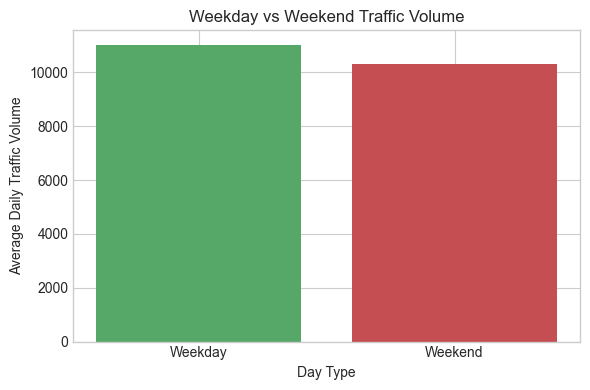

In [10]:
day_type = (
    daily_df.dropna(subset=["is_weekend", "daily_total_volume"])
    .assign(day_type=np.where(daily_df["is_weekend"] == 1, "Weekend", "Weekday"))
    .groupby("day_type", as_index=False)["daily_total_volume"]
    .mean()
)

order = ["Weekday", "Weekend"]
day_type = day_type.set_index("day_type").reindex(order).reset_index()

plt.figure(figsize=(6, 4))
plt.bar(day_type["day_type"], day_type["daily_total_volume"], color=["#55A868", "#C44E52"])
plt.title("Weekday vs Weekend Traffic Volume")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Traffic Volume")
plt.tight_layout()
plt.show()


Day-of-week effects are directly relevant for time-of-day signal plans because commuter-heavy weekday profiles often justify more aggressive peak-period allocation than weekend traffic.


## 6. Peak-Hour Demand Analysis


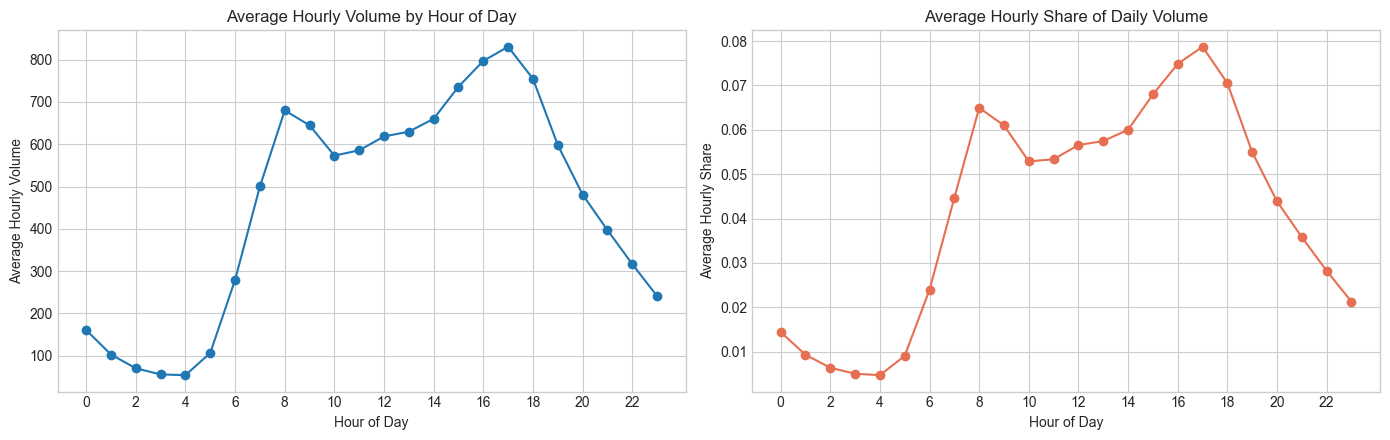

In [11]:
hourly_profile = (
    hourly_df.dropna(subset=["hour_of_day", "hourly_volume"])
    .groupby("hour_of_day", as_index=False)
    .agg(
        avg_hourly_volume=("hourly_volume", "mean"),
        avg_hourly_share=("hourly_share_of_daily_volume", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(hourly_profile["hour_of_day"], hourly_profile["avg_hourly_volume"], marker="o")
axes[0].set_title("Average Hourly Volume by Hour of Day")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Hourly Volume")
axes[0].set_xticks(range(0, 24, 2))

axes[1].plot(hourly_profile["hour_of_day"], hourly_profile["avg_hourly_share"], marker="o", color="#E76F51")
axes[1].set_title("Average Hourly Share of Daily Volume")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Hourly Share")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()


In [12]:
peak_window_summary = hourly_df.assign(
    operational_period=np.select(
        [
            hourly_df["hour_of_day"].between(7, 9),
            hourly_df["hour_of_day"].between(15, 18),
        ],
        ["AM peak", "PM peak"],
        default="Off-peak",
    )
)

peak_window_summary = (
    peak_window_summary.groupby("operational_period", as_index=False)
    .agg(
        avg_hourly_volume=("hourly_volume", "mean"),
        avg_hourly_share=("hourly_share_of_daily_volume", "mean"),
    )
)
display(peak_window_summary)


,operational_period,avg_hourly_volume,avg_hourly_share
0,AM peak,608.334891,0.056884
1,Off-peak,348.987060,0.031604
2,PM peak,779.514798,0.073021


The hourly profile highlights when network pressure is systematically highest. These periods are the natural starting point for baseline signal timing experiments and simulation scenarios.


## 7. Location and Intersection Ranking


In [13]:
top_volume_locations = (
    daily_df.groupby(["location_id", "location_name"], as_index=False)
    .agg(avg_daily_volume=("daily_total_volume", "mean"))
    .sort_values("avg_daily_volume", ascending=False)
    .head(10)
)

top_peak_pressure = (
    daily_df.groupby(["location_id", "location_name"], as_index=False)
    .agg(avg_peak_ratio=("peak_ratio", "mean"))
    .sort_values("avg_peak_ratio", ascending=False)
    .head(10)
)

top_variability = (
    daily_df.groupby(["location_id", "location_name"], as_index=False)
    .agg(volume_std=("daily_total_volume", "std"))
    .sort_values("volume_std", ascending=False)
    .head(10)
)

display(top_volume_locations)
display(top_peak_pressure)
display(top_variability)


,location_id,location_name,avg_daily_volume
735,8417204_WB,Eglinton Ave W: Russell Rd - Islington Ave,37539.285714
534,436600_SB,Yonge St: Nipigon Ave - Steeles Ave W,31405.333333
714,820_SB,Millwood Rd: Laird Dr - Redway Rd,30775.333333
533,436600_NB,Yonge St: Nipigon Ave - Steeles Ave W,30754.333333
835,909165_EB,Dixon Rd: Hwy 427 N / Dixon Ramp - Hwy 427 S,30209.333333
843,909697_EB,Eglinton Ave W: Martin Grove Rd - Hwy 27 / Hwy...,29548.571429
379,20364356_SB,Markham Rd: Select Ave - Steeles Ave E,27778.333333
378,20364356_NB,Markham Rd: Select Ave - Steeles Ave E,27435.666667
871,913167_WB,Dundas St W to West Mall Cres,27410.333333
598,5066262_NB,Kennedy Rd: Brigstock Rd - Ellesmere Rd,26099.428571


,location_id,location_name,avg_peak_ratio
3,10133019_SB,Keele St: Wycombe Rd - Sheppard Ave W,0.583333
619,60000559_WB,Old Finch Ave: Rouge Park Finch Meander Trl - ...,0.209684
18,102945_NB,Meadowvale Rd: Old Finch Ave - Rouge Park Ceda...,0.208191
484,30136114_WB,Matheson Blvd: Eglinton Ave W - Renforth Dr,0.200343
658,6943002_WB,Finch Ave E: Beare Rd - Pickering Town Line,0.200263
23,103008_WB,Old Finch Ave: Sewells Rd - Rouge Park Finch M...,0.197438
17,102880_NB,Meadowvale Rd: Rouge Park Cedar Trl - Plug Hat Rd,0.194056
19,102945_SB,Meadowvale Rd: Old Finch Ave - Rouge Park Ceda...,0.193361
22,103008_EB,Old Finch Ave: Sewells Rd - Rouge Park Finch M...,0.187890
25,103009_SB,Sewells Rd: Old Finch Ave - Steeles Ave E,0.177360


,location_id,location_name,volume_std
2,10133019_NB,Keele St: Wycombe Rd - Sheppard Ave W,8745.161895
902,9544337_SB,Jane St: Alliance Ave - Dalrymple Dr,5265.406733
380,2286559_WB,Steeles Ave W: Petrolia Rd - Keele St,4916.421185
866,912884_EB,Dundas St W: Shorncliffe Rd - Paulart Dr,4685.778677
357,20059039_EB,Steeles Ave W: Keele St - Founders Rd,4461.445708
336,20045619_WB,Steeles Ave W: Walkway E of Islington and S of...,4341.465478
465,30102654_SB,Kipling Ave: Rexdale Blvd - Frost Park Trl,4207.406316
553,439004_WB,Steeles Ave W: Signet Dr - Weston Rd,4145.548784
282,14066563_NB,Port Union Rd: Port Union Rd N / Hwy 401 Colle...,4039.298536
301,14628552_NB,Woodbine Ave: Lane S of Queen and W of Woodbin...,3996.608282


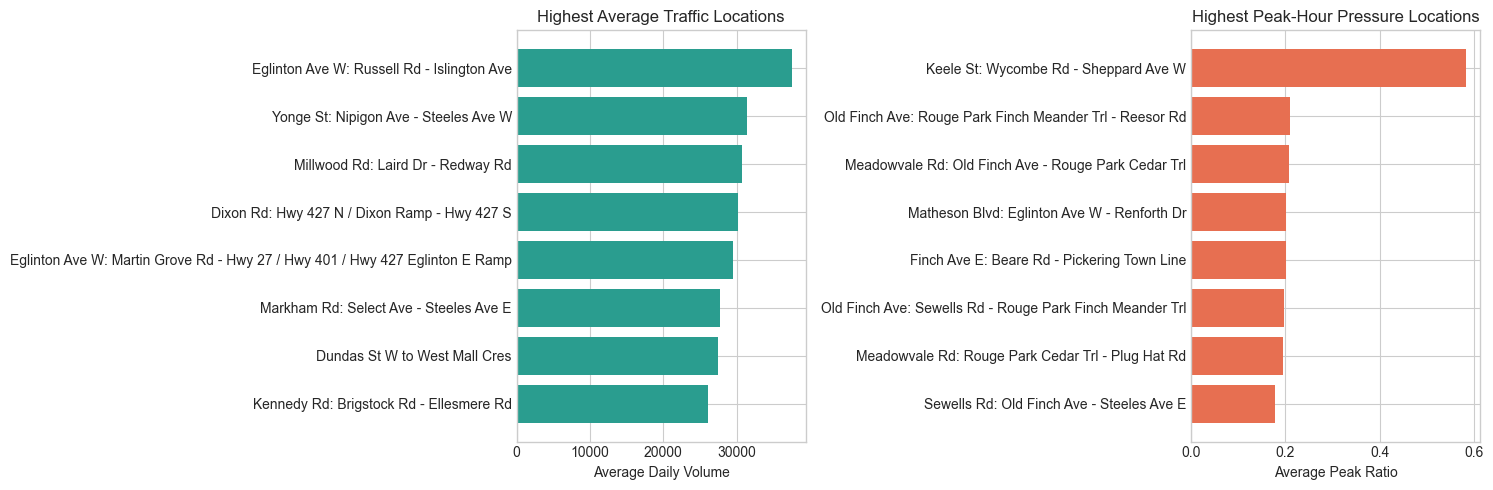

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top_volume_locations["location_name"], top_volume_locations["avg_daily_volume"], color="#2A9D8F")
axes[0].set_title("Highest Average Traffic Locations")
axes[0].set_xlabel("Average Daily Volume")
axes[0].invert_yaxis()

axes[1].barh(top_peak_pressure["location_name"], top_peak_pressure["avg_peak_ratio"], color="#E76F51")
axes[1].set_title("Highest Peak-Hour Pressure Locations")
axes[1].set_xlabel("Average Peak Ratio")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


High-volume sites are not always the same as high-pressure sites. A location with moderate total demand but strong peak concentration can still be a strong candidate for signal optimization because timing changes are most valuable when demand is sharply concentrated.


## 8. Operational Insights


In [15]:
candidate_windows = (
    hourly_df.groupby("hour_of_day", as_index=False)
    .agg(
        avg_hourly_volume=("hourly_volume", "mean"),
        avg_peak_flag=("is_peak_hour", "mean"),
    )
    .sort_values(["avg_hourly_volume", "avg_peak_flag"], ascending=False)
    .head(5)
)

display(candidate_windows)


,hour_of_day,avg_hourly_volume,avg_peak_flag
17,17,830.383870,0.325891
16,16,796.923849,0.118380
18,18,754.812565,0.078747
15,15,735.938906,0.066978
8,8,679.954656,0.236068


The strongest candidates for signal optimization focus are hours that combine high average demand with frequent peak-hour status across locations. Those windows are likely to deliver the clearest operational benefit in later baseline timing and simulation notebooks.


## Outputs

- Input used: `data/processed/modeling_dataset_2015_2019.csv`
- Input used: `data/processed/traffic_signal_hourly_dataset_2015_2019.csv`
- No new persisted dataset is required for this EDA notebook.
